# Univariate TVLA : First-Order and Higher-Order Analysis

⚠️ **Important:** 
This notebook assumes that the **Power Trace Acquisition** notebook has already been executed and the standard AES traceset has been acquired.

### 📓 Notebook Overview: First and Higher-Order TVLA

This notebook demonstrates how to compute first and higher-order univariate Test Vector Leakage Assessment (TVLA) using three approaches:

1. **Custom Code:** From-scratch mathematical implementation.
2. **SciPy:** Standard scientific computing library.
3. **SCALib:** Optimized side-channel library (specifically utilized for the higher-order analysis).

---

### 🔍 What is Univariate TVLA?

Univariate TVLA detects side-channel leakage by splitting measured traces into two sets ($Q_0$ and $Q_1$) and conducting a t-test independently at **each sample point**.

### 🛠️ Evaluation Methods

* **Specific t-test:** 
    **Method:** Traces are split based on a specific intermediate variable (e.g., an AES S-box output bit). This variable must not depend on the specific implementation.
    **Trade-offs:** Provides high confidence if leakage is detected, but must be repeated for *all* possible intermediate variables.


* **Non-specific t-test (Fixed vs. Random):**
    **Method:** The device is fed either a preselected fixed data vector ($D$) or random data. Queries must be randomly interleaved to ensure a random internal state prior to execution.
    **Trade-offs:** Covers all possible intermediate variables in a single test, but with lower statistical confidence than the specific t-test.
    **Note:** To prevent false positives, this test should be repeated using different fixed $D$ values.

In [4]:
import os
from pathlib import Path
import h5py
import numpy as np
import scipy.stats as stats
from scalib.metrics import Ttest
import matplotlib.pyplot as plt

## 1. Configuration and Trace Loading
Load the standard AES S-box traces from the acquired HDF5 traceset and separate them into fixed and random datasets.

In [10]:
# Define paths and TVLA parameters
sbox_id = "rijandael"
n_trc_captured = 20_000 # The total traces captured in the file (10k fixed + 10k random)
n_load = 500            # How many to actually load for the analysis

def find_project_root(start: Path, markers=("fusesoc.conf", ".dojo_root")) -> Path:
    current = start
    while current != current.parent:
        if any((current / m).exists() for m in markers):
            return current
        current = current.parent

    raise RuntimeError(
        f"Could not find project root (looked for markers: {markers}). "
        "Please ensure you are inside the Side-Channel-Dojo repository."
    )


# In a script, __file__ exists; in a notebook, it does not.
try:
    SCRIPT_DIR = Path(__file__).resolve().parent
except NameError:
    # Notebook / interactive: use the current working directory instead
    SCRIPT_DIR = Path.cwd()

DOJO_ROOT = find_project_root(SCRIPT_DIR)

# Traces file path (board-captured traces)
TRACESET_DIR = DOJO_ROOT / "sw" / "traceset" / "AES" / "hw"
TRACESET_FILE = TRACESET_DIR / f"aes_rijandael_20k_tvla.h5"

print(f"Loading traces from: {TRACESET_FILE}")

with h5py.File(TRACESET_FILE, 'r') as f:
    # Load all traces and labels into RAM
    all_traces = np.array(f['traces'])
    labels = np.array(f['labels'])

# Mask for fixed (0) and random (1), then slice exactly 500 of each
traces_fixed = all_traces[labels == 0][:n_load]
traces_random = all_traces[labels == 1][:n_load]

print(f"Loaded {len(traces_fixed)} fixed traces and {len(traces_random)} random traces.")

# ---------------------------------------------------------------------------
# Configuration printout
# ---------------------------------------------------------------------------

def _yn(flag: bool) -> str:
    """Return 'yes' or 'no' for a boolean flag."""
    return "yes" if flag else "no"

print("\n================= TVLA ANALYSIS CONFIGURATION =================")
print(f"DOJO_ROOT           : {DOJO_ROOT}")
print()
print("Target")
print(f"  Cipher            : AES")
print(f"  S-Box             : {sbox_id}")
print(f"  Notebook scope    : AES HW, Univariate TVLA")
print()
print("Dataset")
print(f"  Traces file       : {TRACESET_FILE.name}")
print(f"  Total captured    : {n_trc_captured}")
print(f"  Traces used       : {len(traces_fixed)} fixed / {len(traces_random)} random")
print("===============================================================\n")

Loading traces from: /home/mattia-mirigaldi/Desktop/Side-Channel-Dojo/sw/traceset/AES/hw/aes_rijandael_20k_tvla.h5
Loaded 500 fixed traces and 500 random traces.

================= TVLA ANALYSIS CONFIGURATION =================
DOJO_ROOT           : /home/mattia-mirigaldi/Desktop/Side-Channel-Dojo

Target
  Cipher            : AES (standard permutation)
  S-Box             : rijandael
  Notebook scope    : AES SW, Multivariate TVLA

Dataset
  Traces file       : aes_rijandael_20k_tvla.h5
  Total captured    : 20000
  Traces used       : 500 fixed / 500 random



## 2. First-Order TVLA (Welch's T-Test)

The Welch's t-test determines if the means of two distinct populations (fixed vs. random data) are statistically different at a specific sample point. The manual calculation iterates through every sample to compute the t-statistic:

$$ t = \frac{\bar{X}_{fix} - \bar{X}_{rand}}{\sqrt{\frac{s_{fix}^2}{N_{fix}} + \frac{s_{rand}^2}{N_{rand}}}} $$

### Alternative: Using SciPy
Instead of computing the means and variances manually with nested loops, the exact same first-order evaluation can be achieved quickly using the `scipy` library:

```python
# Import the scipy library for the TVLA analysis 
import scipy.stats as stats

# Perform the Welch's test
t_stat, p_val = stats.ttest_ind(traces_fixed, traces_random, equal_var=False)
```

In [ ]:
def welch_T_test(groupA, groupB):
    """Manual computation of the Welch's t-test."""
    Xa, Xb, Sa, Sb, t_stat = [], [], [], [], []
    N_trace = len(groupA)
    N_sample = len(groupA[0])

    # Compute the mean
    for i in range(N_sample):
        sumA = sum(groupA[k][i] for k in range(N_trace))
        sumB = sum(groupB[k][i] for k in range(N_trace))
        Xa.append(sumA / N_trace)
        Xb.append(sumB / N_trace)

    # Compute the standard deviation
    for i in range(N_sample):
        sumA = sum((groupA[k][i] - Xa[i]) ** 2 for k in range(N_trace))
        sumB = sum((groupB[k][i] - Xb[i]) ** 2 for k in range(N_trace))
        Sa.append((sumA / (N_trace - 1)) ** 0.5)
        Sb.append((sumB / (N_trace - 1)) ** 0.5)

    # Compute the t-statistic
    for i in range(N_sample):
        num = Xa[i] - Xb[i]
        den = ((Sa[i] ** 2) / N_trace + (Sb[i] ** 2) / N_trace) ** 0.5
        t_stat.append(num / den)
        
    return t_stat

# Example using the manual function (on a small subset if it's too slow)
# t_stat_manual = welch_T_test(traces_fixed[:100], traces_random[:100])

# Example using the highly-optimized SciPy function
t_stat_scipy, _ = stats.ttest_ind(traces_fixed, traces_random, equal_var=False)

In [12]:
from bokeh.plotting import figure, show
from bokeh.io import output_notebook
from bokeh.models import CrosshairTool

output_notebook()
p = figure(plot_width=800)

threshold_plus = [4.5] *len(t_stat_scipy)
threshold_minus = [-4.5] *len(t_stat_scipy)

xrange = range(len(t_stat_scipy))
p.line(xrange, t_stat_scipy, line_color="green")
p.line(xrange, threshold_plus, line_color="orange")
p.line(xrange, threshold_minus, line_color="orange")
show(p)

Loading BokehJS ...

## 3. Higher-Order TVLA using Scalib

While the standard t-test works for first-order leakage (mean), evaluating higher-order moments (variance, skewness) manually requires heavy preprocessing (like mean-free squaring). 

**Scalib** automates this and efficiently computes multi-order statistical moments simultaneously. To optimize speed and memory, Scalib strictly requires traces to be mapped into an `int16` format prior to fitting.

In [13]:
# --- 1) Scale float traces to int16 ---
M_fix  = np.max(np.abs(traces_fixed))
M_rand = np.max(np.abs(traces_random))
M = max(M_fix, M_rand)

if M > 0:
    scale = 32767.0 / M
    traces_fix_i16  = np.clip(np.rint(traces_fixed * scale),  -32768, 32767).astype(np.int16)
    traces_rand_i16 = np.clip(np.rint(traces_random * scale), -32768, 32767).astype(np.int16)
else:
    raise ValueError("Traces contain only zeros.")

# --- 2) Prepare TVLA with Scalib ---
# Initialize Ttest up to 3rd order (1=mean, 2=variance, 3=skewness)
ttest = Ttest(3)               

# Assign group classes (0 for fixed, 1 for random)
y_fix  = np.zeros(len(traces_fix_i16),  dtype=np.uint16)
y_rand = np.ones(len(traces_rand_i16), dtype=np.uint16)

# --- 3) Fit and compute ---
ttest.fit_u(traces_fix_i16,  y_fix)
ttest.fit_u(traces_rand_i16, y_rand)

# Returns an array of shape (3, n_samples)
t1_curve, t2_curve, t3_curve = ttest.get_ttest() 

print("Scalib TVLA completed for orders 1 to 3.")

Scalib TVLA completed for orders 1 to 3.


## 4. Plotting the TVLA Results",
Visualizing the $t$-statistic curves for the 1st, 2nd, and 3rd order tests. The red dashed lines represent the $\\pm4.5$ threshold; any peaks crossing these lines indicate statistically significant leakage at that specific order.

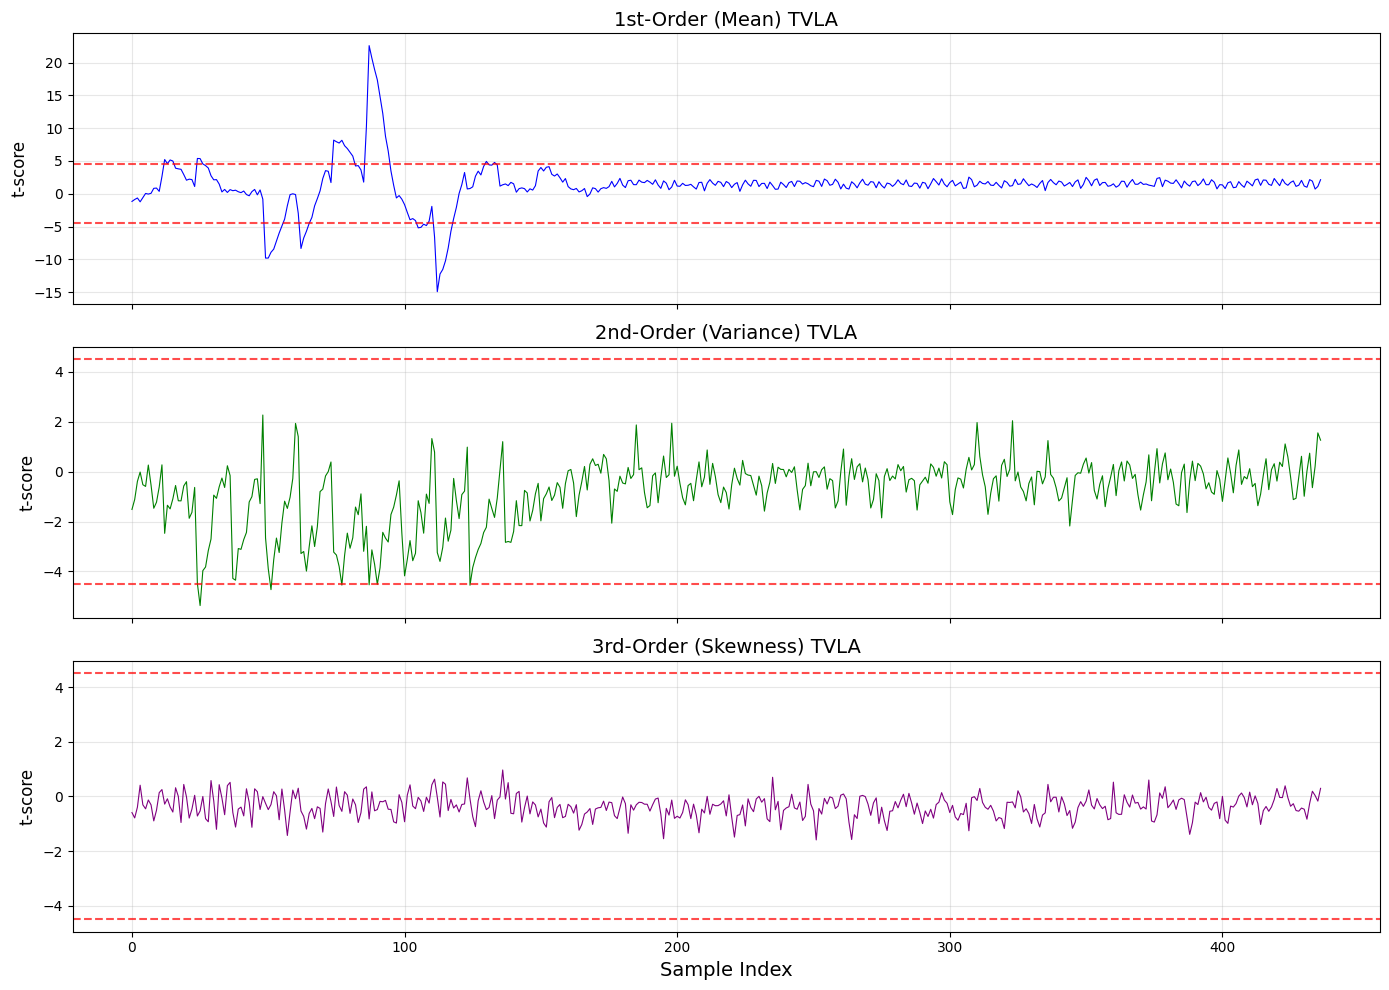

In [14]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

# Define a helper function to format each subplot
def plot_tvla(ax, curve, order_name, color):
    ax.plot(curve, color=color, linewidth=0.8)
    ax.axhline(y=4.5, color='r', linestyle='--', alpha=0.7)
    ax.axhline(y=-4.5, color='r', linestyle='--', alpha=0.7)
    ax.set_title(f"{order_name} TVLA", fontsize=14)
    ax.set_ylabel("t-score", fontsize=12)
    ax.grid(True, alpha=0.3)

# Plot 1st Order (Mean)
plot_tvla(axes[0], t1_curve, "1st-Order (Mean)", 'blue')

# Plot 2nd Order (Variance)
plot_tvla(axes[1], t2_curve, "2nd-Order (Variance)", 'green')

# Plot 3rd Order (Skewness)
plot_tvla(axes[2], t3_curve, "3rd-Order (Skewness)", 'purple')

axes[2].set_xlabel("Sample Index", fontsize=14)
plt.tight_layout()
plt.show()